##Name: Vaishnavi Bagekar
##Roll no. 73
##Aim:

##Dataset link: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
##Collab Link : https://colab.research.google.com/drive/1ZqkZML4hvhEhdsiwRc-gy-GqOulfoCha?usp=sharing

In [1]:
!pip install pandas numpy nltk matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Preprocessing

In [4]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Asus\Downloads\archive\IMDB Dataset.csv", engine="python", on_bad_lines="skip")

In [5]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
def preprocess(text):
  text=text.lower()
  tokens=word_tokenize(text)
  tokens=[word for word in tokens if word.isalpha()]
  tokens=[word for word in tokens if word not in stop_words]
  tokens=[lemmatizer.lemmatize(word) for word in tokens]
  return " ".join(tokens)

data['clean_text']= data['review'].apply(preprocess)
data.head()

,review,sentiment,clean_text
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['sentiment']

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model=MultinomialNB()
model.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [11]:
y_pred=model.predict(X_test)

In [12]:
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Classification Report: \n", classification_report(y_test,y_pred))

Accuracy:  0.8828
Classification Report: 
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4961
    positive       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



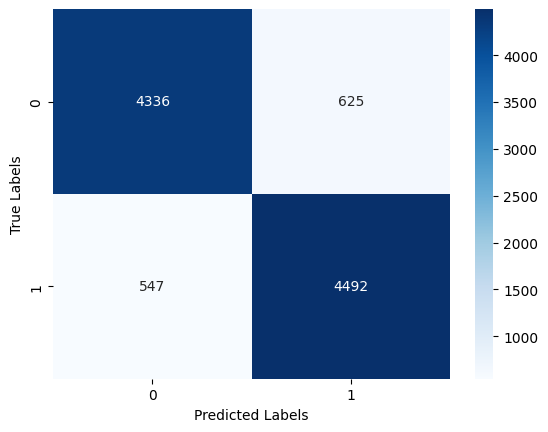

In [13]:

cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=2),

    "Linear SVM": LinearSVC(C=1.5),

    "SGD Classifier": SGDClassifier(loss='hinge', max_iter=2000),

    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=2000),

    "Naive Bayes": MultinomialNB(alpha=0.5),

    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')

    results.append([name, acc, prec, rec, f1])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9032,0.897326,0.912284,0.904743
1,Linear SVM,0.9003,0.897053,0.906132,0.901570
2,SGD Classifier,0.9000,0.888739,0.916253,0.902286
3,Passive Aggressive,0.8921,0.889764,0.897003,0.893369
4,Naive Bayes,0.8834,0.878001,0.892637,0.885259
5,Random Forest,0.8653,0.865834,0.867037,0.866435


In [15]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.7 MB/s eta 0:00:16
   - -------------------------------------- 3.1/101.7 MB 9.7 MB/s eta 0:00:11
   -- ------------------------------------- 5.5/101.7 MB 10.5 MB/s eta 0:00:10
   --- ------------------------------------ 8.9/101.7 MB 11.8 MB/s eta 0:00:08
   ---- ----------------------------------- 12.1/101.7 MB 12.4 MB/s eta 0:00:08
   ------ --------------------------------- 15.5/101.7 MB 13.3 MB/s eta 0:00:07
   ------- -------------------------------- 18.4/101.7 MB 13.5 MB/s eta 0:00:07
   ------- -------------------------------- 20.2/101.7 MB 12.6 MB/s eta 0:00:07
   --------- ------------------------------ 23.3/101.7 MB 13.0 MB/s eta 0:00:07
   ----------- ---------------------------- 28.6/101.7 MB 14.3 MB/s eta 0:00:06
   ------------- -------------------------- 33.3/101.7 MB 15.3 MB/s eta 0:00:05
   -------------- ------------------------- 36.4/101.7 

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(data['sentiment'])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.8198
Precision: 0.7893593919652552
Recall: 0.8724
F1 Score: 0.8288048641459244


In [20]:
!pip install transformers torch

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using c

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\Asus\tf210\lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\Asus\tf210\lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
  File "C:\Users\Asus\tf210\lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "C:\Users\Asus\tf210\lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 104, in read
    self.__buf.write(data)
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\tempfile.py", line 483, in func_wrapper
    return func(*args, **kwargs)
OSError: [Errno 28] No space left on device

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\Asus\tf210\lib\site-packages\pip\_internal\cli\base_command.py", 

In [10]:
!python -m pip install --upgrade pip

In [11]:
!pip install torch --no-cache-dir

   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.7 MB 2.4 MB/s eta 0:00:48
   ---------------------------------------- 1.0/113.7 MB 2.4 MB/s eta 0:00:47
    --------------------------------------- 1.8/113.7 MB 2.7 MB/s eta 0:00:42
    --------------------------------------- 2.6/113.7 MB 3.1 MB/s eta 0:00:36
   - -------------------------------------- 2.9/113.7 MB 3.2 MB/s eta 0:00:36
   - -------------------------------------- 4.2/113.7 MB 3.4 MB/s eta 0:00:33
   -- ------------------------------------- 6.6/113.7 MB 4.6 MB/s eta 0:00:24
   --- ------------------------------------ 9.7/113.7 MB 5.9 MB/s eta 0:00:18
   ---- ----------------------------------- 13.1/113.7 MB 7.1 MB/s eta 0:00:15
   ----- ---------------------------------- 17.0/113.7 MB 8.4 MB/s eta 0:00:12
   ------- -------------------------------- 20.2/113.7 MB 9.0 MB/s eta 0:00:

In [12]:
!pip install transformers

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(data['sentiment'])

# split using RAW TEXT
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    data['review'],
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [14]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

c:\Users\Asus\tf210\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Asus\tf210\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer 

In [26]:
predictions = []

for review in X_test_text[:500]:

    result = sentiment_model(review, truncation=True)[0]['label']

    if result == "POSITIVE":
        predictions.append(1)
    else:
        predictions.append(0)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = y_test_text[:500]

acc = accuracy_score(y_true, predictions)
prec = precision_score(y_true, predictions)
rec = recall_score(y_true, predictions)
f1 = f1_score(y_true, predictions)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.876
Precision: 0.8807692307692307
Recall: 0.8807692307692307
F1 Score: 0.8807692307692307


In [28]:
from transformers import pipeline

sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


Loading weights: 100%|██████████| 104/104 [00:00<?, ?it/s]


In [30]:
final_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "SGD Classifier",
        "Passive Aggressive",
        "Naive Bayes",
        "Random Forest",
        "XGBoost",
        "DistilBERT"
    ],
    "Accuracy":[
        0.855,
        0.860,
        0.864,
        0.861,
        0.852,
        0.827,
        0.820,
        acc
    ]
})

final_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
7,DistilBERT,0.876
2,SGD Classifier,0.864
3,Passive Aggressive,0.861
1,Linear SVM,0.860
0,Logistic Regression,0.855
4,Naive Bayes,0.852
5,Random Forest,0.827
6,XGBoost,0.820


In [31]:
!pip install gradio


  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/42.9 MB 4.2 MB/s eta 0:00:11
    --------------------------------------- 1.0/42.9 MB 3.4 MB/s eta 0:00:13
   - -------------------------------------- 1.3/42.9 MB 2.7 MB/s eta 0:00:16
   - -------------------------------------- 1.8/42.9 MB 2.3 MB/s eta 0:00:18
   - -------------------------------------- 2.1/42.9 MB 2.3 MB/s eta 0:00:19
   -- ------------------------------------- 2.6/42.9 MB 2.1 MB/s eta 0:00:20
   -- ------------------------------------- 2.9/42.9 MB 2.1 MB/s eta 0:00:19
   --- ------------------------------------ 3.4/42.9 MB 2.1 MB/s eta 0:00:19
   ---- ----------------------------------- 4.7/42.9 MB 2.5 MB/s eta 0:00:16
   ---- -------------------

In [34]:
from sklearn.linear_model import SGDClassifier

best_model = SGDClassifier(loss='hinge', max_iter=2000)
best_model.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,2000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [36]:
import pickle

pickle.dump(vectorizer, open("tfidf_vectorizer.pkl","wb"))
pickle.dump(best_model, open("sentiment_model.pkl","wb"))

In [37]:
import pickle

model = pickle.load(open("sentiment_model.pkl", "rb"))
vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

In [38]:
def predict_sentiment(review):

    review_clean = preprocess(review)
    review_vector = vectorizer.transform([review_clean])

    prediction = model.predict(review_vector)[0]

    if prediction == "positive" or prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"

In [39]:
import gradio as gr

interface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Movie Review Sentiment Analysis",
    description="Enter a movie review to predict whether the sentiment is Positive or Negative."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
